# Quantitative analysis of a Gaussian random walk

In this project we construct a Gaussian random walk and simulate many possible paths in order to explore the variability of its trajectories. From these simulations we extract several statistical properties of the process, such as the distribution of returns, volatility behaviour, time–scale dependence, and tail behaviour (kurtosis).

The main objective is to study, through simulation, the statistical properties of a Gaussian random walk and to empirically verify the theoretical predictions of the model.

A second objective is to understand why real financial assets (such as Bitcoin) cannot be accurately described by this simple model. By analysing the statistical structure of the Gaussian random walk, we can identify the assumptions that make the model mathematically elegant but unrealistic when compared with real market behaviour.

# Table of Contents

1. [Python Libraries](#1-python-libraries)
2. [Methodology](#2-methodology)
   - [Construction of a Gaussian random walk](#21-construction-of-a-gaussian-random-walk)
   - [Simulating multiple random walks simultaneously](#22-simulating-multiple-random-walks-simultaneously)
   - [Distribution of final prices](#23-distribution-of-final-prices)
        - [Histogram of final prices](#231-histogram-of-final-prices)
   - [Construction of returns](#24-construction-of-returns)
3. [Statistical properties of the return distribution](#3-statistical-properties-of-the-return-distribution)
   - [QQ plot vs. Normal distribution](#31-qq-plot-vs-normal-distribution)
   - [Histogram of the return distribution vs. Gaussian](#32-histogram-of-the-return-distribution-vs-gaussian)
   - [Four moments of the distribution](#33-four-moments-of-the-distribution)
4. [Volatility scaling (Hurst exponent)](#4-volatility-scaling-hurst-exponent)
   - [Volatility scaling of squared returns](#41-volatility-scaling-of-squared-returns-hurst-exponent)
5. [Tail Analysis](#5-tail-analysis)
   - [Frequency of extreme events](#51-frequency-of-extreme-events)
   - [Estimating alpha power law behavior](#52-estimating-alpha-power-law-behavior)
6. [Autocorrelation](#6-autocorrelation)
   - [Autocorrelation of squared returns](#61-autocorrelation-of-squared-returns)
7. [Summary of empirical findings and implications](#7-summary-of-empirical-findings-and-implications)
8. [References](#8-references)


## 1. Python Libraries 

- **numpy** for numerical processing and logarithmic transformations.
- **matplotlib** for technical visualization of time series and distributions.
- **scipy** for performing statistical tests.
- **statsmodels** for building regressions.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

from scipy.stats import linregress 
from scipy.stats import skew 
from scipy.stats import kurtosis 
from scipy.stats import norm 
from scipy.stats import probplot 

from numpy.lib.stride_tricks import sliding_window_view 
from statsmodels.graphics.tsaplots import plot_acf  

## 2. Methodology

### 2.1 Construction of a Gaussian random walk

A Gaussian random walk is a stochastic process in which each value is obtained by adding a random shock to the previous value. This random shock follows a normal distribution, meaning that each step fluctuates around the previous value according to Gaussian noise:

$$
X_t = X_{t-1} + \epsilon_t
$$

where the random shock satisfies

$$
\epsilon_t \sim N(\mu, \sigma^2)
$$

The key parameters of the model are the number of steps $T$ (in this case each step represents one trading day), the average daily return $\mu$, the daily volatility $\sigma$, and the initial value $p_0$.

Each value $X_t$ can be constructed through a cumulative sum of the random shocks using `cumsum()`. In other words,

$$
X_t = X_{t-1} + \epsilon_t
     = X_{t-2} + \epsilon_{t-1} + \epsilon_t
     = \dots
     = X_0 + \epsilon_1 + \dots + \epsilon_t
$$

Therefore, the process can be generated simply by accumulating Gaussian noise over time.

However, constructing the random walk directly in this way can lead to negative values, which is not appropriate when modelling financial prices. A common solution is to model **log-returns** instead of prices. In that case we obtain

$$
\sum x_i = \ln\left(\frac{S_t}{S_0}\right)
\quad \Rightarrow \quad
S_t = S_0 \cdot e^{\sum x_i}
$$

where $x_i$ represents the return between day $i$ and $i-1$. These returns follow the Gaussian noise introduced above. By exponentiating the cumulative returns, the resulting price $S_t$ is always strictly positive, since the exponential function is always greater than zero.

> By fixing the random seed, the sequence of random numbers remains the same every time the code is executed. This is important for the reproducibility of the results.

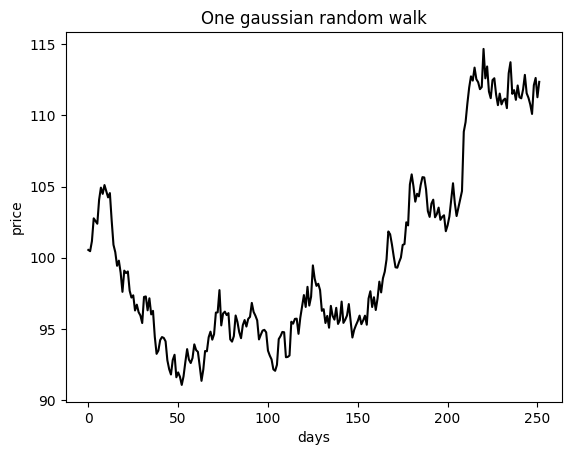

In [ ]:
np.random.seed(42)

mu = 0.0005 #daily mean 
sigma = 0.01 #daily standard deviation
T = 252 #trading days in a year 
S0 = 100 #initial price

epsilon = np.random.normal(loc=mu, scale=sigma, size=T) #tandom variable for each step 
S = S0*np.exp(np.cumsum(epsilon)) 

fig, ax = plt.subplots()

ax.plot(S, color = "black")
ax.set_title("One gaussian random walk")
ax.set_xlabel("days")
ax.set_ylabel("price")

plt.show()

### 2.2 Simulating multiple random walks simultaneously

Now suppose we want to plot not just a single random walk, but thousands of them at once. To do this, we extend the structure of our noise term  $\epsilon$. Instead of generating a single column of random shocks, we generate a **matrix** where each column corresponds to a different simulated path.

In this setup, the rows represent time steps and the columns represent independent random walks. This allows us to simulate many trajectories in parallel using vectorized operations.

Since we are now working with a matrix, it is important to specify the axis along which the cumulative sum is computed. The cumulative sum must be taken along the **time axis**, so that the shocks accumulate through time within each individual path.

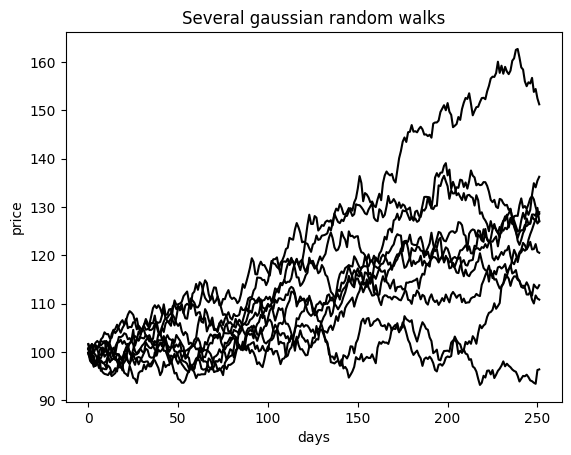

In [ ]:
np.random.seed(42)
N = 10

epsilon = np.random.normal(loc=mu, scale=sigma, size=(T,N))

S = S0*np.exp(np.cumsum(epsilon, axis=0)) 

fig, ax = plt.subplots()
ax.plot(S, color = "black") 
ax.set_title("Several gaussian random walks")
ax.set_xlabel("days")
ax.set_ylabel("price")

plt.show()



### 2.3 Distribution of final prices

In order to analyse the statistical properties of the simulated paths, we focus on the final value of each random walk. This corresponds to the last element of each trajectory, which can be accessed using `[-1]`.

The idea is straightforward: we simulate many independent random walks, extract the final price from each path, and then study the distribution of these values. A simple way to visualize this is by plotting a histogram of the final prices obtained from all simulated paths.

In [4]:
np.random.seed(42)
N = 10000
epsilon = np.random.normal(loc=0.0005, scale=0.01, size=(T,N))
S = S0*np.exp(np.cumsum(epsilon, axis=0))
final_prices = S[-1]



#### 2.3.1 Histogram of final prices

We first visualize the distribution of the final prices using a histogram. The resulting distribution follows a **log-normal shape**, characterized by a relatively short left tail and a longer right tail.

This occurs because, although the **returns are normally distributed**, prices are obtained by exponentiating the cumulative returns. As a result, the price distribution becomes log-normal rather than normal.

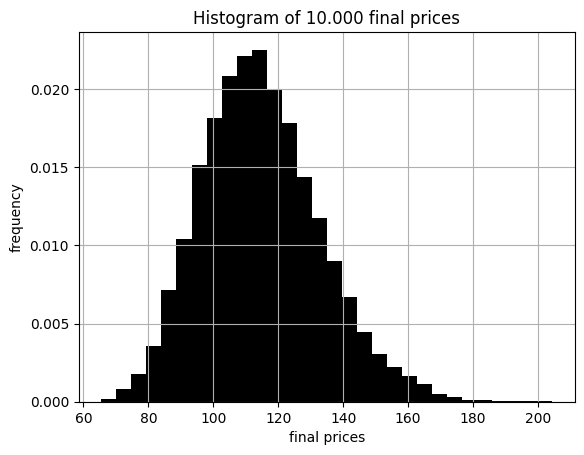

In [5]:
fig, ax = plt.subplots()
ax.hist(final_prices, color= "black", bins= 30, density= True)
ax.set_title("Histogram of 10.000 final prices")
ax.grid(True)
ax.set_ylabel("frequency")
ax.set_xlabel("final prices")

plt.show()

This is an interesting point: although returns are normally distributed, prices are not. When we exponentiate cumulative returns, the resulting distribution becomes log-normal. As a consequence, the distribution exhibits a longer right tail. 

This asymmetry arises naturally from the multiplicative nature of price dynamics.

### 2.4 Construction of returns

The Gaussian distribution in this model does not apply to prices (which follow a log-normal distribution) but to **returns**. Returns correspond to the daily increments that build the price along each random walk.

All the statistical analysis in this project will therefore be performed on **returns rather than prices**.

It is important to note that returns are **not computed from differences between final prices**, since those correspond to different random walks observed at the same time. Instead, returns must be calculated as **changes in price within the same random walk across consecutive time steps**.

For a random walk with $T = 252$ time steps, we obtain $T-1 = 251$ returns, which correspond to the successive increments that generated the trajectory. Since returns in a Gaussian random walk are assumed to be **independent and identically distributed (i.i.d.)**, we can combine the returns from all simulated paths. With 1000 simulated random walks, this yields a total of **251,000 returns**, providing a much larger sample for statistical analysis.

> At the beginning of the simulation we generated the random shocks $\epsilon_t$, which effectively represent the returns. From these returns we constructed the price paths. Here we are simply recovering the returns again from the simulated prices.

> Because we compute returns using logarithms, the first observation of each path cannot be defined (there is no previous price), which results in a `NaN`. Consequently, each path contributes $T-1$ valid return observations.

In [ ]:
N = 1000

returns = np.diff(np.log(S), axis=0)
returns = returns[~np.isnan(returns)]
returns = returns.flatten()  

## 3. Statistical properties of the return distribution

### 3.1 QQ Plot vs. Normal Distribution

To begin, we visualize how much our return distribution deviates from a normal distribution.  
Since the model assumes Gaussian shocks, the deviation should be minimal.

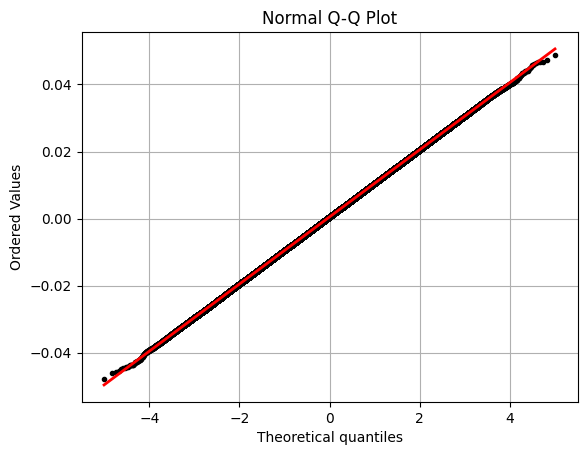

In [7]:
fig, ax = plt.subplots()
probplot(returns, dist="norm", fit= True, plot=ax)
ax.get_lines()[0].set_color("black")   
ax.get_lines()[1].set_color("red")
ax.get_lines()[1].set_linewidth(2)
ax.get_lines()[0].set_markersize(3)
ax.set_title("Normal Q-Q Plot")
ax.grid(True)

plt.show()

### 3.2 Histogram of the return distribution vs. Gaussian

To quickly visualize the distribution of returns obtained from the simulated price paths over the chosen time interval, we use a histogram.It can be helpful to plot the histogram of our simulated returns alongside the corresponding Gaussian curve with the same mean and standard deviation.  

This allows us to visually assess how well the normal distribution approximates the return distribution of the Gaussian random walk.

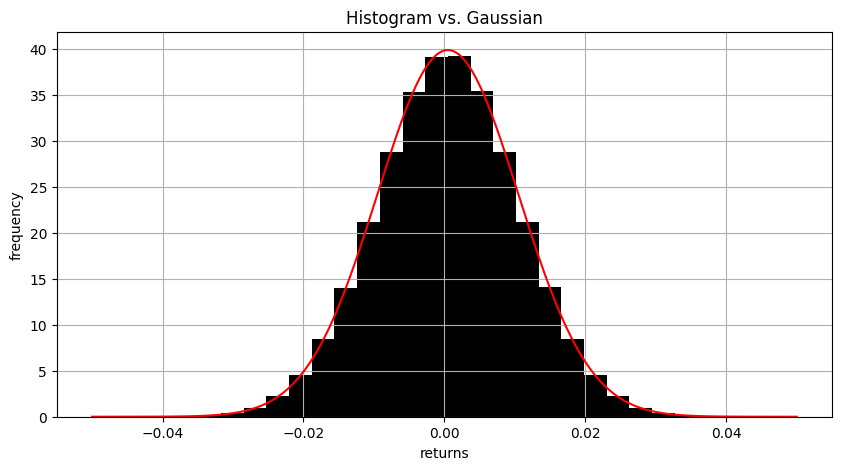

In [ ]:
mu = np.mean(returns)
sigma = np.std(returns)

x = np.linspace(-0.050,0.050,1000)
y = norm.pdf(x, loc=mu, scale=sigma)

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(x,y, color="red")
ax.hist(returns, color= "black", bins= 30, density= True)
ax.set_title("Histogram vs. Gaussian")
ax.grid(True)
ax.set_ylabel("frequency")
ax.set_xlabel("returns")

plt.show()

Indeed, we can see that the Gaussian curve (red line) fits our return distribution almost perfectly.  

This is far from a trivial result: one might initially assume that simply aggregating returns that are individually normal would automatically produce a normal distribution. What this visual observation shows empirically is that our sample size is large enough to justify this approximation.  

Additionally, it confirms that both the returns within a single random walk and the returns across different random walks over the same time interval are independent of each other.

### 3.3 Four moments of the distribution

Next, we calculate the **mean**, **standard deviation**, **skewness**, and **kurtosis** to formally characterize the statistical properties of our return distribution.

In [9]:
print(f"Mean: {np.mean(returns):.4f}")
print(f"Standard deviation: {np.std(returns):.4f}")
print(f"Skewness: {skew(returns):.4f}")
print(f"Excess kurtosis: {kurtosis(returns):.4f}")

Mean: 0.0005
Standard deviation: 0.0100
Skewness: -0.0006
Excess kurtosis: -0.0003


Although we included a small drift when constructing our random walk, the returns themselves should not be significantly affected by it, as reflected in the mean being practically zero.

It is also unsurprising that the distribution is perfectly symmetric and that the excess kurtosis is effectively zero.

> Note: skewness would appear if we were analyzing the **final prices** instead of returns, since in that case the distribution would be log-normal, exhibiting a longer right tail than left.

## 4. Volatility scaling (Hurst exponent)

Theoretically, the volatility of the return distribution should scale with the square root of time as we increase the time horizon. In other words:

$$
\sigma(\Delta t) \propto (\Delta t)^H
$$

with $H \approx 0.5$, the **Hurst exponent**.

To verify this, we compute the standard deviation of returns for different time horizons and plot it on a **log–log scale** against the time horizon. Since we are using logarithms on both axes, the scaling relation transforms to: $$\log(\sigma) = H \cdot \log(\Delta t) + \text{constant}$$



Slope: 0.4997
R: 0.99999989


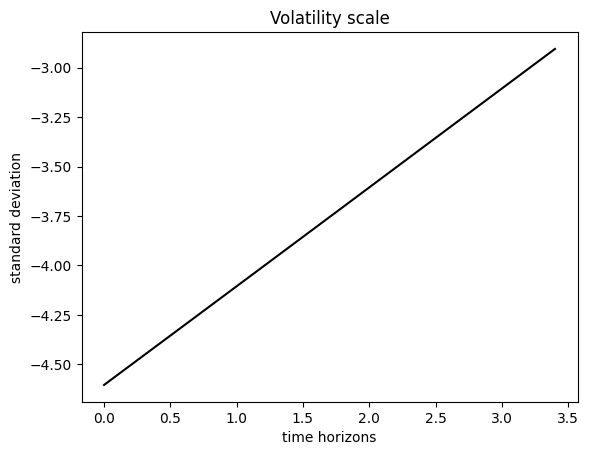

In [ ]:
horizons = [1,2,3,5,10,15,20,30]
 
sigmas = []
for i in horizons:
    windows = sliding_window_view(returns, window_shape=i) 
    sum_returns = windows.sum(axis=-1) #we should clarify if we want to colapse columns or rows 
    sigmas.append(np.std(sum_returns))


sigmas_log = np.log(sigmas)
horizons_log = np.log(horizons) 


fig, ax = plt.subplots()
ax.plot(horizons_log, sigmas_log, color="black")
ax.set_title("Volatility scale")
ax.set_xlabel("time horizons")
ax.set_ylabel("standard deviation")

result = linregress(horizons_log, sigmas_log)
print(f"Slope: {result.slope:.4f}")
print(f"R: {result.rvalue:.8f}")

Unsurprisingly, the estimated Hurst exponent comes out very close to the theoretical value, as expected for a Gaussian random walk.

Visually, we can plot the standard deviation of returns as a function of the time horizon alongside the theoretical square-root-of-time scaling.  

In this plot, the **black line** represents the observed standard deviation from our simulated data, while the **red points** correspond to the expected values assuming the volatility scales as \(\sqrt{t}\).

Text(0, 0.5, 'standard deviation')

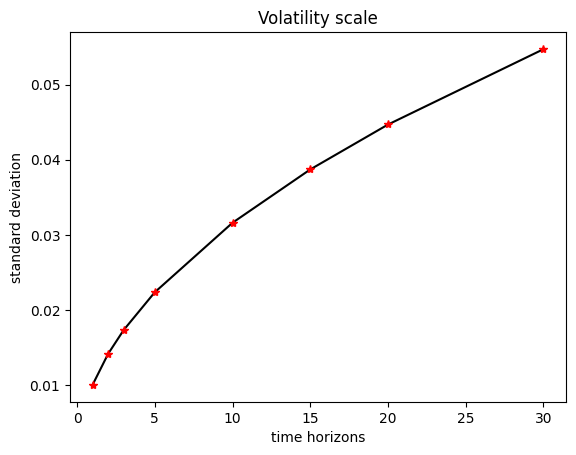

In [ ]:
sigma = 0.01  

fig, ax = plt.subplots()
ax.plot(horizons, sigmas, color="black")
ax.plot(horizons,sigma*np.sqrt(np.array(horizons)),"*", color= "red")
ax.set_title("Volatility scale")
ax.set_xlabel("time horizons")
ax.set_ylabel("standard deviation")

We can see that the standard deviation calculated from our simulated data matches perfectly the expected scaling with the time horizon.

### 4.1 Volatility scaling of squared returns (Hurst exponent)

It is important to perform this check because, for most real financial assets, while the standard deviation of returns scales roughly as the square root of time, it is in the **absolute or squared returns** that a Hurst exponent different from 0.5 can be observed.  
A deviation from 0.5 in this context would indicate **long-term dependence** and **volatility clustering**.

In our case, we expect the exponent to be around 0.5 as well, since Gaussian distributions are characterized by **i.i.d. increments**.  
Here we use squared returns without concern for outliers destabilizing the model, because the underlying returns are Gaussian, making extreme values highly unlikely. 

Slope: 0.4993
R: 0.99999988


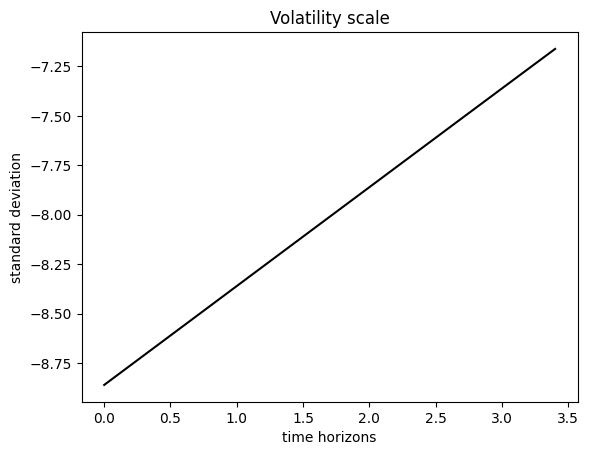

In [ ]:
QR_returns = returns**2
horizons = [1,2,3,5,10,15,20,30]

sigmas = []
for i in horizons:
    windows = sliding_window_view(QR_returns, window_shape=i) 
    sum_returns = windows.sum(axis=-1) 
    sigmas.append(np.std(sum_returns))
    
sigmas_log = np.log(sigmas)
horizons_log = np.log(horizons) 


fig, ax = plt.subplots()
ax.plot(horizons_log, sigmas_log, color="black")
ax.set_title("Volatility scale")
ax.set_xlabel("time horizons")
ax.set_ylabel("standard deviation")

result = linregress(horizons_log, sigmas_log)
print(f"Slope: {result.slope:.4f}")
print(f"R: {result.rvalue:.8f}")

As expected, we obtain a Hurst exponent very close to the theoretical value. Note that, although the two Hurst exponents appear identical, they actually differ starting from the fourth decimal place.

This confirms that the process is **diffusive**, meaning that the volatility scales exactly as expected for a Gaussian process, following a square-root-of-time law.

## 5. Tail analysis

Unlike most real financial assets, we expect extreme events in a Gaussian random walk to decay **exponentially**.  

To investigate this, we compare the probability of events exceeding a certain number of standard deviations $\sigma$ for both the Gaussian distribution and our simulated return distribution. We then attempt to estimate the exponent that would govern the tails if they were **heavy-tailed**.

### 5.1 Frequency of extreme events

We compare events exceeding 2, 3, and 4 standard deviations $\sigma$ for both the normal distribution and our simulated return distribution to see how well they match.  

> For convenience, the empirical distribution has been **rescaled** so that it can be compared with a Gaussian distribution with mean 0 and standard deviation 1.

In [ ]:
returns_norm = (returns - mu)/sigma #Standarization 

sigmas = [2 ,3, 4]
for i in sigmas: 
    prob =  100*np.mean(returns_norm > i)
    normi = 100*norm.cdf(-i) 
    print(f"{i}-sigma event probability: {prob:.4f}% vs. {normi:.4f}% (Gaussian)")

2-sigma event probability: 2.2756% vs. 2.2750% (Gaussian)
3-sigma event probability: 0.1376% vs. 0.1350% (Gaussian)
4-sigma event probability: 0.0025% vs. 0.0032% (Gaussian)


We observe that the frequencies of extreme events follow exactly what we would expect from a Gaussian distribution. Although the exact magnitudes may not match perfectly, the probabilities align very well.  

This provides further evidence that our returns are indeed Gaussian: the likelihood of increasingly extreme events decreases exactly as it would in a normal distribution. We will verify this more formally in the next section.

### 5.2 Estimating alpha (power-law behavior)

If our distribution followed a power-law, we would expect an exponent $\alpha$ between 2 and 4. In our case, however, we observe a much larger exponent, consistent with the exponential decay expected for Gaussian tails. 

In [ ]:
x = np.sort(returns)
N = len(x)
y = (N - np.arange(N) - 1) / N 


threshold = np.percentile(x, 99)
mask = (x >= threshold) & (y > 0)
log_x = np.log(x[mask])
log_y = np.log(y[mask])
result = linregress(log_x, log_y)
print(f"Alfa for 99th percentile: {- result.slope:.2f}") 

Alfa for 99th percentile: 9.23


Indeed, we observe that the estimated $\alpha$ is far too large to classify the distribution as heavy-tailed. In other words, for a distribution composed of Gaussian random walks, the tails decay **exponentially**. This confirms that the extreme values of our distribution follow Gaussian/exponential behavior.

> Note: in this analysis, we only considered the 99th percentile, focusing on the extreme right-hand tail.

## 6. Autocorrelation

Here, we examine whether the returns are uncorrelated, as expected since Gaussian increments are i.i.d.  
To do this, we select a single Gaussian random walk (the first one, for convenience) and compare the list of returns with its $n$-th lag.

> We do not use all returns to avoid excessive computation time.


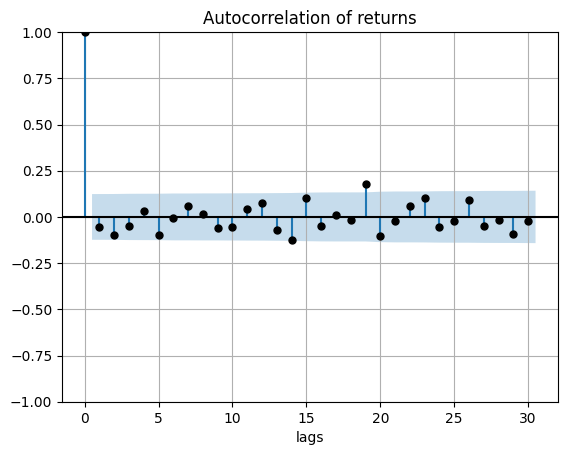

In [ ]:
S1 = S[:,1] #first random walk prices
returns_1 = np.diff(np.log(S1), axis=0)
returns_1 = returns_1[~np.isnan(returns_1)]

fig, ax = plt.subplots()
plot_acf(returns_1, lags=30, ax=ax, color= "black")

ax.set_title("Autocorrelation of returns")
ax.set_xlabel("lags")

ax.grid()

plt.show()

### 6.1 Autocorrelation of squared returns

We now perform the same analysis on **squared returns** to check for any structure or long-term dependence.  
At first glance, this might look like we are examining correlations between prices over time, but in fact these prices are simply the cumulative sum of returns over time (so the analysis is equivalent).

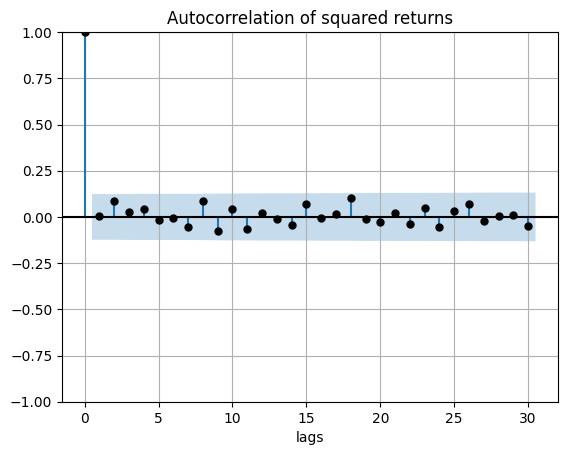

In [ ]:
fig, ax = plt.subplots()
plot_acf(returns_1**2, lags=30, ax=ax, color= "black")

ax.set_title("Autocorrelation of squared returns")
ax.set_xlabel("lags")
ax.grid()

plt.show()

In both cases, we observe that the autocorrelation of returns and squared returns at non-zero lags is practically zero, which is sufficient to consider the series as **white noise**. This confirms that the process exhibits **no temporal memory**.

> Obviously, the autocorrelation at lag 0 is 1, since we are correlating the series with itself.

## 7. Summary of Empirical Findings and Implications

- The **returns of a Gaussian random walk** follow a normal distribution, while the corresponding prices are log-normally distributed due to exponentiation.  
- All **four moments** (mean, standard deviation, skewness, kurtosis) confirm the Gaussian nature of the returns: symmetric, nearly zero skewness, and negligible excess kurtosis.  
- **Volatility scales** with the square root of time, and the Hurst exponent is close to 0.5 for both returns and squared returns, confirming a **diffusive process with i.i.d. increments**.  
- **Tail behavior** follows exponential decay; estimated α values are too large to indicate heavy tails, consistent with Gaussian assumptions.  
- **Autocorrelation analysis** shows that both returns and squared returns are effectively uncorrelated, confirming the absence of temporal memory and volatility clustering.  

**Implications:** The Gaussian random walk captures basic statistical properties of returns, but unlike real assets, it does not generate heavy tails, long-range dependence, or volatility clustering. This highlights the limitations of simple Gaussian models in capturing real-world market dynamics.



## 8. References

- Mantegna, R. N., & Stanley, H. E. (2000). *An Introduction to Econophysics: Correlations and Complexity in Finance. Cambridge University Press.*

- MIT OpenCourseWare. *Mathematics in Applications to Finance*. https://ocw.mit.edu
